# 86 - Pretraining with an Autoencoder (CIFAR-10)

**Section:** Transfer Learning | **Prereqs:** `CNN Milestone Projects/CIFAR_10_AutoEncoder.ipynb` | **Next:** `Transfer Learning/Pretraining_with_AutoEncoders.ipynb`

Transfer learning without a pretrained model to borrow. Train an autoencoder on
your *own unlabelled* data, then reuse its encoder as a feature extractor for
classification.

**Two stages**
1. **Pretrain (self-supervised).** Train the autoencoder to reconstruct images.
   No labels are used, so this can consume as much unlabelled data as you have.
2. **Fine-tune (supervised).** Copy the encoder into a classifier, freeze it,
   and train only the new head on labelled data.

**Why it matters.** Labels are expensive; raw data usually is not. This is the
whole premise of self-supervised learning - and the same idea, at scale, is how
language models are trained: a pretext task with free labels, then a small
supervised head.

**The mechanics to copy:** `model.encoder.state_dict()` extracts one *part* of a
model, and `load_state_dict` pours it into a matching part of another. The
architectures must match exactly - which is why the encoder block in the
classifier is copied verbatim from the autoencoder.

**An honest caveat about this notebook:** reconstruction and classification want
different features. An autoencoder must keep whatever is needed to rebuild the
image, including background and colour that a classifier does not care about. So
autoencoder pretraining usually helps less than supervised pretraining, and
modern self-supervised methods (SimCLR, MAE) use pretext tasks designed to
produce discriminative features instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset

import torchvision
import torchsummary

from sklearn.model_selection import train_test_split

In [2]:
# CIFAR-10.
train = torchvision.datasets.CIFAR10('/',True, download=True)
test = torchvision.datasets.CIFAR10('/',False, download=True)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


In [3]:
train.data.shape, test.data.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [4]:
train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /
    Split: Train

In [5]:
train_data = train.data
train_label = train.targets

test_data = test.data
test_label = test.targets

In [6]:
# permute to (N,C,H,W) and scale to [0,1]; 80/20 train/validation split.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data, val_data , train_label , val_label = train_test_split(train_data, train_label, train_size=0.80)

train_dataset = TensorDataset(torch.tensor(train_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(train_label, dtype=torch.long,device=device))
val_dataset = TensorDataset(torch.tensor(val_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(val_label, dtype=torch.long,device=device))

test_dataset = TensorDataset(torch.tensor(test_data, dtype=torch.float,device=device).permute(0, 3, 1, 2) / 255., torch.tensor(test_label, dtype=torch.long,device=device))

In [7]:
# DataLoaders

bs = 256

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [8]:
# The autoencoder from CNN Milestone Projects/CIFAR_10_AutoEncoder.ipynb.
# Fully convolutional - the latent is a (4*chan_num, 4, 4) spatial map, not a
# vector.
# forward returns both the reconstruction and the latent; the LATENT is the part
# that will be reused.
# Trying the nn.Upsample + nn.Conv in the decoder layer.


class Autoencoder(nn.Module):
    def __init__(self, chan_num=32):
        super().__init__()

        # ---- Encoder (no flatten, no linear) ----
        self.encoder = nn.Sequential(
            # Block 1: 3x32x32 -> chan_num x 32x32 -> 16x16
            nn.Conv2d(3, chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 2: chan_num x 16x16 -> 2*chan_num x 16x16 -> 8x8
            nn.Conv2d(chan_num, 2*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(2*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 3: 2*chan_num x 8x8 -> 4*chan_num x 8x8 -> 4x4
            nn.Conv2d(2*chan_num, 4*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(4*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),
        )
        self.latent_channels = 4 * chan_num   # latent shape: [B, 4*chan_num, 4, 4]

        # ---- Decoder (mirror of encoder, no linear layers) ----
        self.decoder = nn.Sequential(
            # Upsample 4x4 -> 8x8
            nn.ConvTranspose2d(4*chan_num, 2*chan_num, kernel_size=2, stride=2),
            nn.BatchNorm2d(2*chan_num),
            nn.LeakyReLU(inplace=True),

            # Upsample 8x8 -> 16x16
            nn.ConvTranspose2d(2*chan_num, chan_num, kernel_size=2, stride=2),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(inplace=True),

            # Upsample 16x16 -> 32x32
            nn.ConvTranspose2d(chan_num, 3, kernel_size=2, stride=2),
            nn.Sigmoid()   # output in [0,1] for normalized images
        )

    def forward(self, x):
        latent_map = self.encoder(x)         # [B, 4*chan_num, 4, 4]
        reconstruction = self.decoder(latent_map)  # [B, 3, 32, 32]
        return reconstruction, latent_map


In [9]:
# STAGE 1: self-supervised pretraining. MSE between reconstruction and input.
# The labels in the loader are discarded (`for x, _ in`) - this stage would work
# on completely unlabelled data.
def train_autoencoder(chan_num, epochs=50, lr=1e-3, l1_lambda=0):
    model = Autoencoder(chan_num).to(device)
    recon_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4,
        betas=(0.9, 0.999)
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x, _ in train_loader:
            x = x.to(device)
            recon, latent = model(x)
            loss = recon_loss_fn(recon, x)

            if l1_lambda > 0:
                l1_norm = torch.abs(latent).mean()
                loss = loss + l1_lambda * l1_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            X_val, _ = next(iter(val_loader))
            X_val = X_val.to(device)
            recon_val, _ = model(X_val)
            val_loss = recon_loss_fn(recon_val, X_val).item()
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

    return model, train_losses, val_losses


In [10]:
# Pretrain with chan_num=512.
model, train_losses, val_losses = train_autoencoder(512)

Epoch   0 | Train Loss: 0.027266 | Val Loss: 0.020688
Epoch  10 | Train Loss: 0.008511 | Val Loss: 0.017114
Epoch  20 | Train Loss: 0.004455 | Val Loss: 0.006856
Epoch  30 | Train Loss: 0.004228 | Val Loss: 0.006034
Epoch  40 | Train Loss: 0.004138 | Val Loss: 0.007903
Epoch  49 | Train Loss: 0.004090 | Val Loss: 0.005709


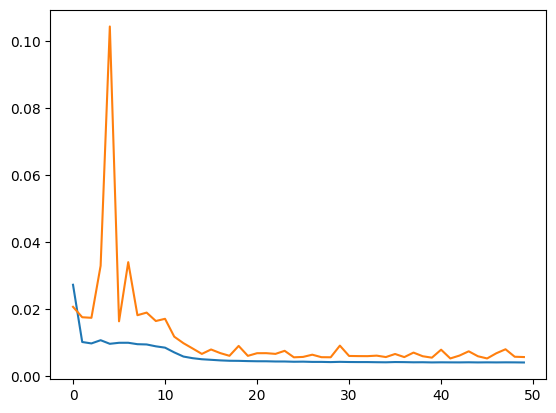

In [11]:
# Reconstruction loss. Once it plateaus the encoder has learned a compact
# representation, which is all that stage 2 needs.
plt.plot(train_losses)
plt.plot(val_losses);


In [22]:
# THE HANDOFF: extract just the encoder's weights.
# state_dict() works on any submodule, not only the whole model - that is what
# makes partial transfer a one-liner.
# Now we extract the encoder layer
ecoder_weights = model.encoder.state_dict()

In [13]:
# The classifier: the SAME encoder architecture, verbatim, plus a classification
# head instead of a decoder.
# The architectures must match exactly for load_state_dict to accept the weights,
# which is why the block is duplicated rather than reimagined.
class classifier(nn.Module):
    def __init__(self, chan_num=32):
        super().__init__()

        # ---- Encoder (no flatten, no linear) ----
        self.encoder = nn.Sequential(
            # Block 1: 3x32x32 -> chan_num x 32x32 -> 16x16
            nn.Conv2d(3, chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 2: chan_num x 16x16 -> 2*chan_num x 16x16 -> 8x8
            nn.Conv2d(chan_num, 2*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(2*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),

            # Block 3: 2*chan_num x 8x8 -> 4*chan_num x 8x8 -> 4x4
            nn.Conv2d(2*chan_num, 4*chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(4*chan_num),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(2, 2),
        )

        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*chan_num * 4 * 4, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self, x):
        latent_map = self.encoder(x)         # [B, 4*chan_num, 4, 4]
        return self.linear_layers(latent_map)


In [32]:
# Build the classifier with matching width (chan_num=512).
classifier_model = classifier(chan_num=512).to(device)
classifier_model

classifier(
  (encoder): Sequential(
    (0): Conv2d(3, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01, inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01, inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(1024, 2048, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01, inplace=True)
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (linear_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, 

In [33]:
# torchsummary. Note how many parameters sit in the flatten -> Linear boundary.
torchsummary.summary(classifier_model, (3,32,32),bs, device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [256, 512, 32, 32]          14,336
       BatchNorm2d-2         [256, 512, 32, 32]           1,024
         LeakyReLU-3         [256, 512, 32, 32]               0
         AvgPool2d-4         [256, 512, 16, 16]               0
            Conv2d-5        [256, 1024, 16, 16]       4,719,616
       BatchNorm2d-6        [256, 1024, 16, 16]           2,048
         LeakyReLU-7        [256, 1024, 16, 16]               0
         AvgPool2d-8          [256, 1024, 8, 8]               0
            Conv2d-9          [256, 2048, 8, 8]      18,876,416
      BatchNorm2d-10          [256, 2048, 8, 8]           4,096
        LeakyReLU-11          [256, 2048, 8, 8]               0
        AvgPool2d-12          [256, 2048, 4, 4]               0
          Flatten-13               [256, 32768]               0
           Linear-14                 [2

In [34]:
# Load the pretrained encoder weights. This raises immediately on any shape or
# name mismatch, which is the behaviour you want.
classifier_model.encoder.load_state_dict(ecoder_weights)

<All keys matched successfully>

In [35]:
# Freeze the encoder: the pretrained features are fixed and only the head learns.
# Same pattern as the ResNet notebook, with weights you produced yourself.
for name, params in classifier_model.encoder.named_parameters():
  params.requires_grad_(False)

In [36]:
# Verify the freeze before training - a silent failure here is indistinguishable
# from 'pretraining did not help'.
for name, params in classifier_model.named_parameters():
  print(f'Name : {name} : Requires Grad : {params.requires_grad}')

Name : encoder.0.weight : Requires Grad : False
Name : encoder.0.bias : Requires Grad : False
Name : encoder.1.weight : Requires Grad : False
Name : encoder.1.bias : Requires Grad : False
Name : encoder.4.weight : Requires Grad : False
Name : encoder.4.bias : Requires Grad : False
Name : encoder.5.weight : Requires Grad : False
Name : encoder.5.bias : Requires Grad : False
Name : encoder.8.weight : Requires Grad : False
Name : encoder.8.bias : Requires Grad : False
Name : encoder.9.weight : Requires Grad : False
Name : encoder.9.bias : Requires Grad : False
Name : linear_layers.1.weight : Requires Grad : True
Name : linear_layers.1.bias : Requires Grad : True
Name : linear_layers.3.weight : Requires Grad : True
Name : linear_layers.3.bias : Requires Grad : True
Name : linear_layers.5.weight : Requires Grad : True
Name : linear_layers.5.bias : Requires Grad : True


In [37]:
# STAGE 2: supervised training of the head only.
# The optimizer is given every parameter, but the frozen ones have no gradient
# and never move. filter(lambda p: p.requires_grad, ...) would be more explicit.
#
# For a real comparison, train an identical classifier from random weights and
# put the two accuracy curves side by side - that difference is what pretraining
# bought.
def train_classifier(model, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(), # Only trainable parameters will be optimized
        lr=lr,
        weight_decay=5e-4,
        betas=(0.9, 0.999)
    )

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            X_val, y_val = next(iter(val_loader))
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            outputs_val = model(X_val)
            val_loss = criterion(outputs_val, y_val).item()
            val_losses.append(val_loss)

            _, predicted = torch.max(outputs_val.data, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()
            val_accuracy = 100 * correct / total
            val_accuracies.append(val_accuracy)

        if epoch % 1 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Acc: {val_accuracy:.2f}%')

    return model, train_losses, val_losses, val_accuracies

In [39]:
# Train the classifier head.
model, train_losses, val_losses, val_accuracies = train_classifier(classifier_model)

Epoch   0 | Train Loss: 0.967654 | Val Loss: 0.996090 | Val Acc: 65.08%
Epoch   1 | Train Loss: 0.950349 | Val Loss: 0.993341 | Val Acc: 65.33%
Epoch   2 | Train Loss: 0.952261 | Val Loss: 1.007418 | Val Acc: 64.75%
Epoch   3 | Train Loss: 0.945467 | Val Loss: 0.998185 | Val Acc: 65.04%
Epoch   4 | Train Loss: 0.937375 | Val Loss: 0.999519 | Val Acc: 64.91%
Epoch   5 | Train Loss: 0.926273 | Val Loss: 1.005244 | Val Acc: 65.24%
Epoch   6 | Train Loss: 0.926099 | Val Loss: 0.992943 | Val Acc: 65.55%
Epoch   7 | Train Loss: 0.923811 | Val Loss: 0.979462 | Val Acc: 65.91%
Epoch   8 | Train Loss: 0.923549 | Val Loss: 0.984936 | Val Acc: 65.47%
Epoch   9 | Train Loss: 0.914289 | Val Loss: 0.963971 | Val Acc: 66.33%
